# Regularization - Ridge & Lasso

The Auto MPG data concerns city-cycle fuel consumption in miles per gallon. It has 398 instances a nd 9 attributes. 8 attributes are quantitative amongst which 3 are multi-valued
 discrete while 5 are continuous. All these attributes refer to specifications of a particular car.

You have to predict value of Miles Per Gallon given other attributes by applying Linear Regression Model and Regularization Techniques (L1 & L2).

Data Dictionary:

1. **MPG:** MPG is Miles Per Gallon. This is the amount of fuel consumed by the particular vehicle of an instance. It is a continues variable. This variable is the target variable.
2. Cylinders: This attribute describes the number of cylinders of each car. This is a discrete valued attribute.
3. Displacement: This is another attribute of the vehicle which has a quantitative continues value describing the engine displacement.
4. Horsepower: This attribute tells about the horsepower of a car and is a continues valued variable.
5. Weight: This refers to the weight of each car which is a continues valued quantitative.
6. Acceleration: The acceleration of the car.
7. Model Year:The year the model was released is mentioned in this attribute.
8. Origin: The origin attribute has 3 discrete values. 1 refers to cars made in USA, 2 for Europe and 3 for Asian.
9. Car Name:This is the name of the car in string.


### Reading Libraries

In [1]:
#import the libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
matplotlib.rcParams.update({'font.size': 12})
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
## Read the Data
mpg_df = pd.read_csv("car-mpg.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'car-mpg.csv'

In [ ]:
mpg_df.shape

In [ ]:
#Head
mpg_df.head()

In [ ]:
mpg_df.info()

In [ ]:
mpg_df['hp'].unique()

In [ ]:
mpg_df['hp']=mpg_df['hp'].replace('?',np.nan)

In [ ]:
mpg_df['hp'].unique()

In [ ]:
mpg_df=mpg_df.dropna()

In [ ]:
mpg_df = mpg_df.drop('car_name', axis=1)# Dropping becouse it will act as a noise
mpg_df['origin'] = mpg_df['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})

In [ ]:
mpg_df.head()

In [ ]:
mpg_df = pd.get_dummies(mpg_df, columns=['origin'], drop_first=True, dtype=int)

In [ ]:
mpg_df

In [ ]:
mpg_df.dtypes

In [ ]:
mpg_df["hp"]=mpg_df["hp"].astype("float64")## Changing the data type of "hp" column to integer

**Null Value Check**

In [ ]:
mpg_df.isnull().sum()

**Describe**

In [ ]:
mpg_df.describe()

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols=2)

a=sns.distplot(mpg_df['mpg'],ax=axes[0][0])
a.set_title("mpg distplot",fontsize=10)

a=sns.boxplot(mpg_df['mpg'],orient='h',ax=axes[0][1])
a.set_title("mpg boxplot",fontsize=10)

a=sns.distplot(mpg_df['hp'],ax=axes[1][0])
a.set_title("hp distplot",fontsize=10)

a=sns.boxplot(mpg_df['hp'],orient='h',ax=axes[1][1])
a.set_title("hp boxplot",fontsize=10)

**Univariate Analysis**

In [ ]:
fig, axes = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,25)
a = sns.distplot(mpg_df['cyl'] , ax=axes[0][0])
a.set_title("cyl Distribution",fontsize=10)

a = sns.boxplot(mpg_df['cyl'] , orient = "h" , ax=axes[0][1])
a.set_title("cyl Boxplot",fontsize=10)

a = sns.distplot(mpg_df['disp'] , ax=axes[1][0])
a.set_title("disp Distribution",fontsize=10)

a = sns.boxplot(mpg_df['disp'] , orient = "v" , ax=axes[1][1])
a.set_title("disp Boxplot",fontsize=10)


a = sns.distplot(mpg_df['wt'] , ax=axes[2][0])
a.set_title("wt Distribution",fontsize=10)

a = sns.boxplot(mpg_df['wt'] , orient = "v" , ax=axes[2][1])
a.set_title("wt Boxplot",fontsize=10)


a = sns.distplot(mpg_df['acc'] , ax=axes[3][0])
a.set_title("acc Distribution",fontsize=10)

a = sns.boxplot(mpg_df['acc'] , orient = "v" , ax=axes[3][1])
a.set_title("acc Boxplot",fontsize=10)

a = sns.distplot(mpg_df['hp'] , ax=axes[4][0])
a.set_title("hp Distribution",fontsize=10)

a = sns.boxplot(mpg_df['hp'] , orient = "v" , ax=axes[4][1])
a.set_title("hp Boxplot",fontsize=10)

a = sns.distplot(mpg_df['mpg'] , ax=axes[5][0])
a.set_title("mpg Distribution",fontsize=10)

a = sns.boxplot(mpg_df['hp'] , orient = "v" , ax=axes[5][1])
a.set_title("mpg Boxplot",fontsize=10)

plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(10,10)
a = sns.distplot(mpg_df['mpg'] , ax=axes[0][0])
a.set_title("mpg Distribution",fontsize=10)

a = sns.boxplot(mpg_df['mpg'] , orient = "v" , ax=axes[0][1])
a.set_title("mpg Boxplot",fontsize=10)

a = sns.distplot(mpg_df['hp'] , ax=axes[1][0])
a.set_title("hp Distribution",fontsize=10)

a = sns.boxplot(mpg_df['hp'] , orient = "v" , ax=axes[1][1])
a.set_title("hp Boxplot",fontsize=10)

In [ ]:
##Two Columns "acc" and "hp" seems to have outliers present. We are going to treat them  though IQR Method.

**Treating outliers in the 2 variables**

In [ ]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [ ]:
Outlier=["acc","hp","mpg"]

In [ ]:
for i in Outlier:
    lr,ur=remove_outlier(mpg_df[i])
    mpg_df[i]=np.where(mpg_df[i]> ur,ur,mpg_df[i])
    mpg_df[i]=np.where(mpg_df[i]< lr,lr,mpg_df[i])


In [ ]:
sns.boxplot(mpg_df["acc"])

In [ ]:
plt.figure(figsize=(10,10))
mpg_df.drop("mpg",axis=1).boxplot(vert=0)

In [ ]:
## Now, No outliers are present in the data set

Training Data and Testing Data

In [ ]:
X=mpg_df.drop('mpg',axis=1)
y=mpg_df[['mpg']]

In [ ]:
##Ideally Scaling should be apllied

In [ ]:
from sklearn import preprocessing

# scale all the columns of the mpg_df. This will produce a numpy array
X_scaled = preprocessing.scale(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)  # ideally the training and test should be

y_scaled = preprocessing.scale(y)
y_scaled = pd.DataFrame(y_scaled, columns=y.columns)  # ideally the training and test should be

In [ ]:
X.head()

In [ ]:
X_scaled.head()

In [ ]:
y.head()

In [ ]:
y_scaled.head()

In [ ]:
## Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.30, random_state=1)
print(len(X_test), len(y_test))

In [ ]:
print(len(X_train), len(y_train))

## Linear Regression using sklearn

In [ ]:
# invoke the LinearRegression function and find the bestfit model on training data
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_train,y_train)

In [ ]:
regression_model.coef_

In [ ]:
prediction_train=regression_model.predict(X_train)

In [ ]:
prediction_test=regression_model.predict(X_test)

In [ ]:
from sklearn import metrics

In [ ]:
# R square on training data
train_score=metrics.r2_score(y_train,prediction_train)
train_score

In [ ]:
# R square on training data
test_score=metrics.r2_score(y_test,prediction_test)
test_score

In [ ]:
# Calculate MSE on train data set
import math
mse = np.mean((regression_model.predict(X_train)-y_train)**2)
math.sqrt(mse)

In [ ]:
# Calculate MSE on test data set
import math
mse = np.mean((regression_model.predict(X_test)-y_test)**2)
math.sqrt(mse)

# Regularization

Regularization is a technique used for tuning the function by adding an additional penalty term in the error function. The additional term controls the excessively fluctuating function such that the coefficients don't take extreme values

## Ridge

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[0.1,1,5,10,20,30,35,40,45,50,55,100]}## Appllying Grid Search
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55,
                                   100]},
             scoring='neg_mean_squared_error')

In [ ]:
print(ridge_regressor.best_params_)## Best value for the Parameter

{'alpha': 1}


In [ ]:
from sklearn.linear_model import Ridge## Building the Model with the best parameter value
ridge_regressor = Ridge(alpha = 1)
ridge_regressor.fit(X_train, y_train)

Ridge(alpha=1)

In [ ]:
prediction_train=ridge_regressor.predict(X_train)

In [ ]:
prediction_test=ridge_regressor.predict(X_test)

In [ ]:
# R square on training data
train_score=metrics.r2_score(y_train,prediction_train)
train_score

0.842825880203518

In [ ]:
# R square on testing data
train_score=metrics.r2_score(y_test,prediction_test)
train_score

0.8389743064690782

In [ ]:
regression_model.coef_

array([[ 0.35422659,  0.25747052, -0.18736989, -0.68365327,  0.05276747,
         0.33802275,  0.40039922,  0.12918962,  0.08765672]])

In [ ]:
ridge_regressor.coef_

array([ 0.3354746 ,  0.22798771, -0.19134408, -0.65015834,  0.04690905,
        0.33449621,  0.38634464,  0.1277083 ,  0.08465075])

In [ ]:
# Let us explore the coefficients for each of the independent attributes

for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, ridge_regressor.coef_[0][idx]))

IndexError: invalid index to scalar variable.

 # Lasso

In [ ]:
#Optimizing for alpha
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[0.1,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.1, 1, 5, 10, 20, 30, 35, 40, 45, 50, 55,
                                   100]},
             scoring='neg_mean_squared_error')

In [ ]:
lasso_regressor.best_params_

{'alpha': 0.1}

In [ ]:
from sklearn.linear_model import Lasso
lasso_regressor = Lasso(alpha =  0.1 )
lasso_regressor.fit(X_train,y_train)

Lasso(alpha=0.1)

In [ ]:
prediction_train=lasso_regressor.predict(X_train)

In [ ]:
prediction_test=lasso_regressor.predict(X_test)

In [ ]:
# R square on training data
train_score=metrics.r2_score(y_train,prediction_train)
train_score

0.7968783834774978

In [ ]:
# R square on training data
test_score=metrics.r2_score(y_test,prediction_test)
test_score

0.810539123320202

In [ ]:
lasso_regressor.coef_

array([-0.        , -0.        , -0.06378676, -0.46364738,  0.        ,
        0.25310606,  0.14847944,  0.00394294,  0.        ])

## Let us compare the compare the coefficients after and before regularization

**Before: Linear Regression**

In [ ]:
regression_model.coef_

array([[ 0.33239887,  0.2677487 , -0.13101739, -0.72457027,  0.07184274,
         0.34268704,  0.38859997, -0.07614017,  0.06386192,  0.02969322]])

**After:**

**Ridge**

In [ ]:
ridge_regressor.coef_

array([[ 0.31531978,  0.2367341 , -0.13683986, -0.68864465,  0.0653182 ,
         0.3389272 ,  0.3756066 , -0.07485716,  0.06396076,  0.02794813]])

**We can see a slight drop in almost all the coefficients**

**Ridge regression shrinks the coefficients and it helps to reduce the model complexity and multi-collinearity.**

**Lasso**

In [ ]:
lasso_regressor.coef_

array([-0.        , -0.        , -0.0393942 , -0.47787441,  0.        ,
        0.25871994,  0.13707307, -0.02931066,  0.        ,  0.        ])

The Lasso Model dropped 5 dimensions by making there coefficients zero without compromising much at the performance part. Without losing much accuracy we have reduced the number of dimensions to be used for model building.

**Lasso method overcomes the disadvantage of Ridge regression by not only punishing high values of the coefficients β but actually setting them to zero if they are not relevant. Therefore, you might end up with fewer features included in the model than you started with, which is a huge advantage.**

**Depending on the regularization strength, certain weights can become zero, which makes the LASSO method a very powerful technique for dimensionality reduction or feature selection.**

# UNDER AND OVER _ FITTING

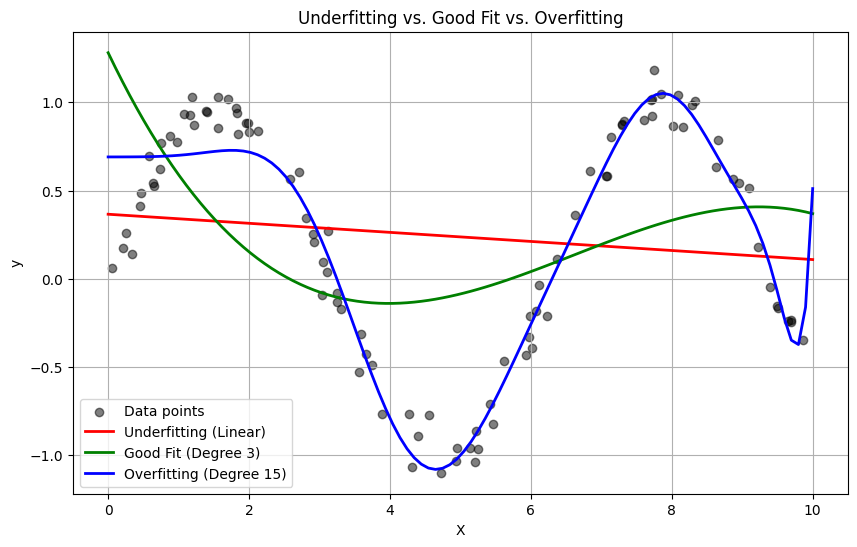

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generate sample data (sine wave with noise)
np.random.seed(42)
X = np.sort(10 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(100) * 0.1  # True trend + noise

# Prepare test points for smooth curves
X_test = np.linspace(0, 10, 100).reshape(-1, 1)

# 1. Underfitting: Linear model (too simple)
underfit_model = LinearRegression()
underfit_model.fit(X, y)
y_underfit = underfit_model.predict(X_test)

# 2. Good fit: Polynomial degree 3 (reasonable complexity)
goodfit_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
goodfit_model.fit(X, y)
y_goodfit = goodfit_model.predict(X_test)

# 3. Overfitting: Polynomial degree 15 (too complex)
overfit_model = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
overfit_model.fit(X, y)
y_overfit = overfit_model.predict(X_test)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Data points', alpha=0.5)
plt.plot(X_test, y_underfit, color='red', label='Underfitting (Linear)', linewidth=2)
plt.plot(X_test, y_goodfit, color='green', label='Good Fit (Degree 3)', linewidth=2)
plt.plot(X_test, y_overfit, color='blue', label='Overfitting (Degree 15)', linewidth=2)

# Labels and styling
plt.xlabel('X')
plt.ylabel('y')
plt.title('Underfitting vs. Good Fit vs. Overfitting')
plt.legend()
plt.grid(True)
plt.show()

**Underfitting**: A straight line that misses most of the data points (too simple).

**Good fit**: A smooth curve that captures the general trend.

**Overfitting**: A wiggly curve that hits every single training point, including noise.

What You’ll See

Underfitting (Red Line): A straight line that misses the sinusoidal trend entirely—too simple to capture the data’s pattern.

Good Fit (Green Curve): A smooth curve that follows the general sine wave trend without chasing every noise point.

Overfitting (Blue Curve): A wiggly line that fits almost every data point, including the noise, making it erratic and unlikely to generalize.

---------------------------------------------------------------------------------

**Exactly**! Overfitting means a model performs poorly on test or unseen data, and here’s why:

When a model overfits, it learns not just the underlying patterns in the training data but also the noise, outliers, and random quirks specific to that dataset. Think of it as memorizing the exact answers to a practice test instead of understanding the concepts for a new exam. When you give it unseen data (the test set), those quirks and noise don’t exist in the same way, so the model’s predictions go haywire—it can’t generalize.